In [1]:
# import all the E9 stuff
import logging
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import time

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c
import E9_fn.E9_atom as E9a
import E9_fn.E9_cooltrap as E9ct
import E9_fn.plane_wave_expansion.blochstate_class as bsc
# import E9_fn.polarizabilities_calculation as E9pol
# import E9_fn.datasets.transition_line_data as TLData
from E9_fn import util

# Logging
logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


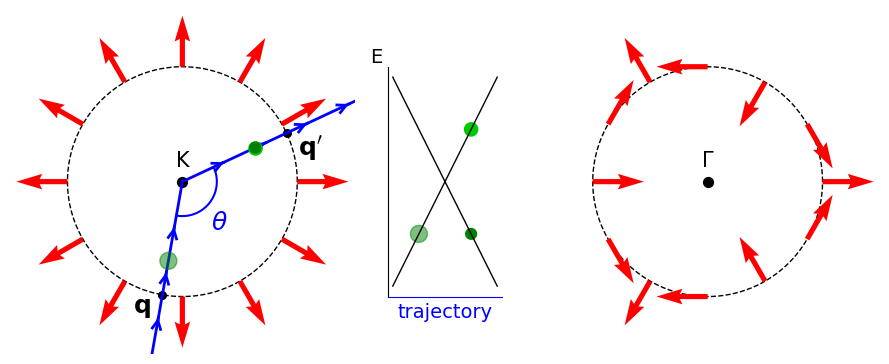

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (9, 4), width_ratios = [3,1,3])

n_arrows = 12  # Number of arrows per circle
theta = np.linspace(0, 2*np.pi, n_arrows, endpoint=False)
cl_band1 = "green"
cl_band2 = "#00ca00"

x_circ = np.cos(theta)
y_circ = np.sin(theta)
quiver_scale = 0.15
for ax, wn, str_TP in zip(axes[::2], [1, 2], ["K", r"$\Gamma$"]):   # wn: winding number
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)

    util.draw_circle(ax, (0, 0), 1, color = 'black', linestyle = '--', lw = 1)
    ax.scatter([0], [0], color='black', s = 50)
    ax.text(0, 0.1, str_TP, va = "bottom", ha = "center", fontsize = 15)

    x_arr = np.cos(theta * wn)
    y_arr = np.sin(theta * wn)
    ax.quiver(x_circ, y_circ, x_arr, y_arr, color = "red",
    # edgecolor = "black", linestyle = "-", linewidth = 0.3,
    angles = 'xy', scale_units = 'xy', scale = 15 * quiver_scale,
    width = 0.1 * quiver_scale,
    zorder = 5)

# Trajectory
l_traj = 2
theta_in, theta_out = np.deg2rad(-100), np.deg2rad(25)
c_i, s_i = np.cos(theta_in), np.sin(theta_in)
c_o, s_o = np.cos(theta_out), np.sin(theta_out)
util.add_line_with_arrows(axes[0], [l_traj * c_i, 0], [l_traj * s_i, 0],
                        num_arrows = 4, color = 'blue', lw = 2, arr_kwargs = {"arrowstyle": "->"})
util.add_line_with_arrows(axes[0], [0, l_traj * c_o], [0, l_traj * s_o],
                        num_arrows = 4, color = 'blue', lw = 2, arr_kwargs = {"arrowstyle": "->"})
util.draw_circle(axes[0], (0, 0), 0.3, theta_range = (theta_in, theta_out), close_circle = False,
                 color = 'blue', linestyle = '-', lw = 1.5)
axes[0].text(0.25, -0.25, r"$\theta$", va = "top", ha = "left",
             color = 'blue', fontsize = 18)

# Atoms in the LBTP q-space plot
l_a = 0.7
axes[0].scatter(l_a * np.array([c_i, c_o]), l_a * np.array([s_i, s_o]), s = [150, 60],
                alpha = [0.5, 1], color = cl_band1, zorder = 90)
axes[0].scatter(l_a *c_o, l_a * s_o, s = 90, alpha = 1, color = cl_band2, zorder = 80)

# q label
axes[0].scatter(c_i, s_i, color = 'black', s = 30)
axes[0].text(c_i - 0.1, s_i, r"$\mathbf{q}$", va = "top", ha = "right",
             color = "black", fontsize = 18)
axes[0].scatter(c_o, s_o, color = 'black', s = 30)
axes[0].text(c_o + 0.1, s_o - 0.0, r"$\mathbf{q}'$", va = "top", ha = "left",
             color = "black", fontsize = 18)

# Dirac point
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].spines["bottom"].set_color("blue")
axes[1].set_aspect('equal')
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].set_xlabel("trajectory", color = "blue", fontsize = 14)
axes[1].set_ylabel("E", loc = "top", rotation = "horizontal", fontsize = 14)

axes[1].plot([-0.6, 0.6], [-1.2, 1.2], color = 'black', lw = 1)
axes[1].plot([-0.6, 0.6], [1.2, -1.2], color = 'black', lw = 1)
axes[1].scatter([-0.3, 0.3, 0.3], [-0.6, 0.6, -0.6], s = [150, 90, 60], alpha = [0.5, 1, 1],
                color = [cl_band1, cl_band2, cl_band1])
# util.draw_circle(axes[1], [0, -0.55], 0.2, theta_range = [np.deg2rad(160), np.deg2rad(20)],
#                  close_circle = False, color = "green", lw = 2)

fig.tight_layout()

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\geometric_probe")
file_full_path = Path(thesis_fig_path, "exp_seq_comic.pdf")
# fig.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches = 'tight')